# Grocery store Customers Analysis 

# Objective:
1. To analysed grocery store customer purchasing behavior. 
2. To segment customers into different group using K-Means clustering.
3. To Help grocery stores optimize inventory & improve customer experience.

# Problem Statement:
Grocery store collect large amounts of customer purchasing data, but they struggleto identifying customer segments and predicting purchasing behavior can help businesses:
1. Improve product ewcommendations.
2. Optimize stock and supply chain management.
this project aims to develop a clustering  mosel to segment customers amd a classification model to predict customer categories based on their purchasing habits.

# Target Audience:
This model is designed for customer success teams and marketing departments to proactively address customer retention by identifying high-risk accounts.


In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [3]:
# Load your dataset 
df = pd.read_csv(r"C:\Users\vishal\Desktop\Dataset\customers.csv")
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


# Get summary of DataFrame

In [4]:
# Quick overview of the data
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicatessen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicatessen      440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


# Get descriptive statistics

In [6]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


# EDA

In [7]:
#Data Preprocessing (Scale the data to normalize numerical values)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.iloc[:, 2:])  # Exclude non-numeric features

# Correlation matrix with Heat map

                   Channel    Region     Fresh      Milk   Grocery    Frozen  \
Channel           1.000000  0.062028 -0.169172  0.460720  0.608792 -0.202046   
Region            0.062028  1.000000  0.055287  0.032288  0.007696 -0.021044   
Fresh            -0.169172  0.055287  1.000000  0.100510 -0.011854  0.345881   
Milk              0.460720  0.032288  0.100510  1.000000  0.728335  0.123994   
Grocery           0.608792  0.007696 -0.011854  0.728335  1.000000 -0.040193   
Frozen           -0.202046 -0.021044  0.345881  0.123994 -0.040193  1.000000   
Detergents_Paper  0.636026 -0.001483 -0.101953  0.661816  0.924641 -0.131525   
Delicatessen      0.056011  0.045212  0.244690  0.406368  0.205497  0.390947   

                  Detergents_Paper  Delicatessen  
Channel                   0.636026      0.056011  
Region                   -0.001483      0.045212  
Fresh                    -0.101953      0.244690  
Milk                      0.661816      0.406368  
Grocery                 

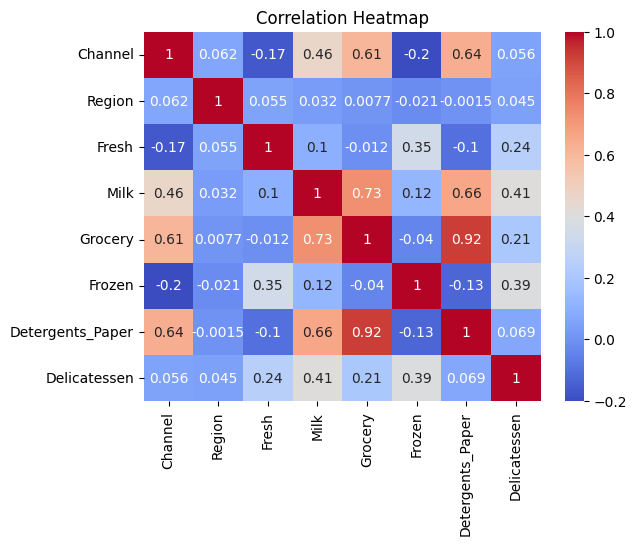

In [8]:
# correlation matrix
corr=df.corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm' )
plt.title("Correlation Heatmap")
plt.show()

# For Elbow curve calculate inertia

In [9]:
# Calculate inertia for different numbers of clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

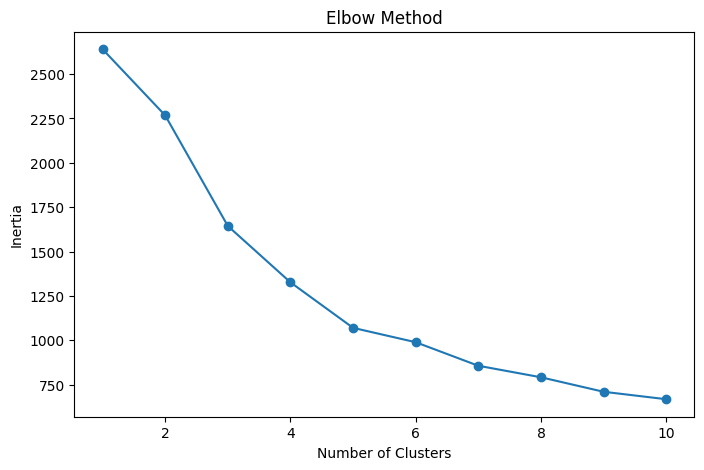

In [10]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

 # K-means Clustering

In [11]:
# Apply K-Means with Optimal Clusters 
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [12]:
# Add cluster labels to the original dataset
df['Cluster'] = clusters
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicatessen  Cluster  
0          1338        0  
1          1776        0  
2          7844        0  
3          1788        0  
4          5185        1  


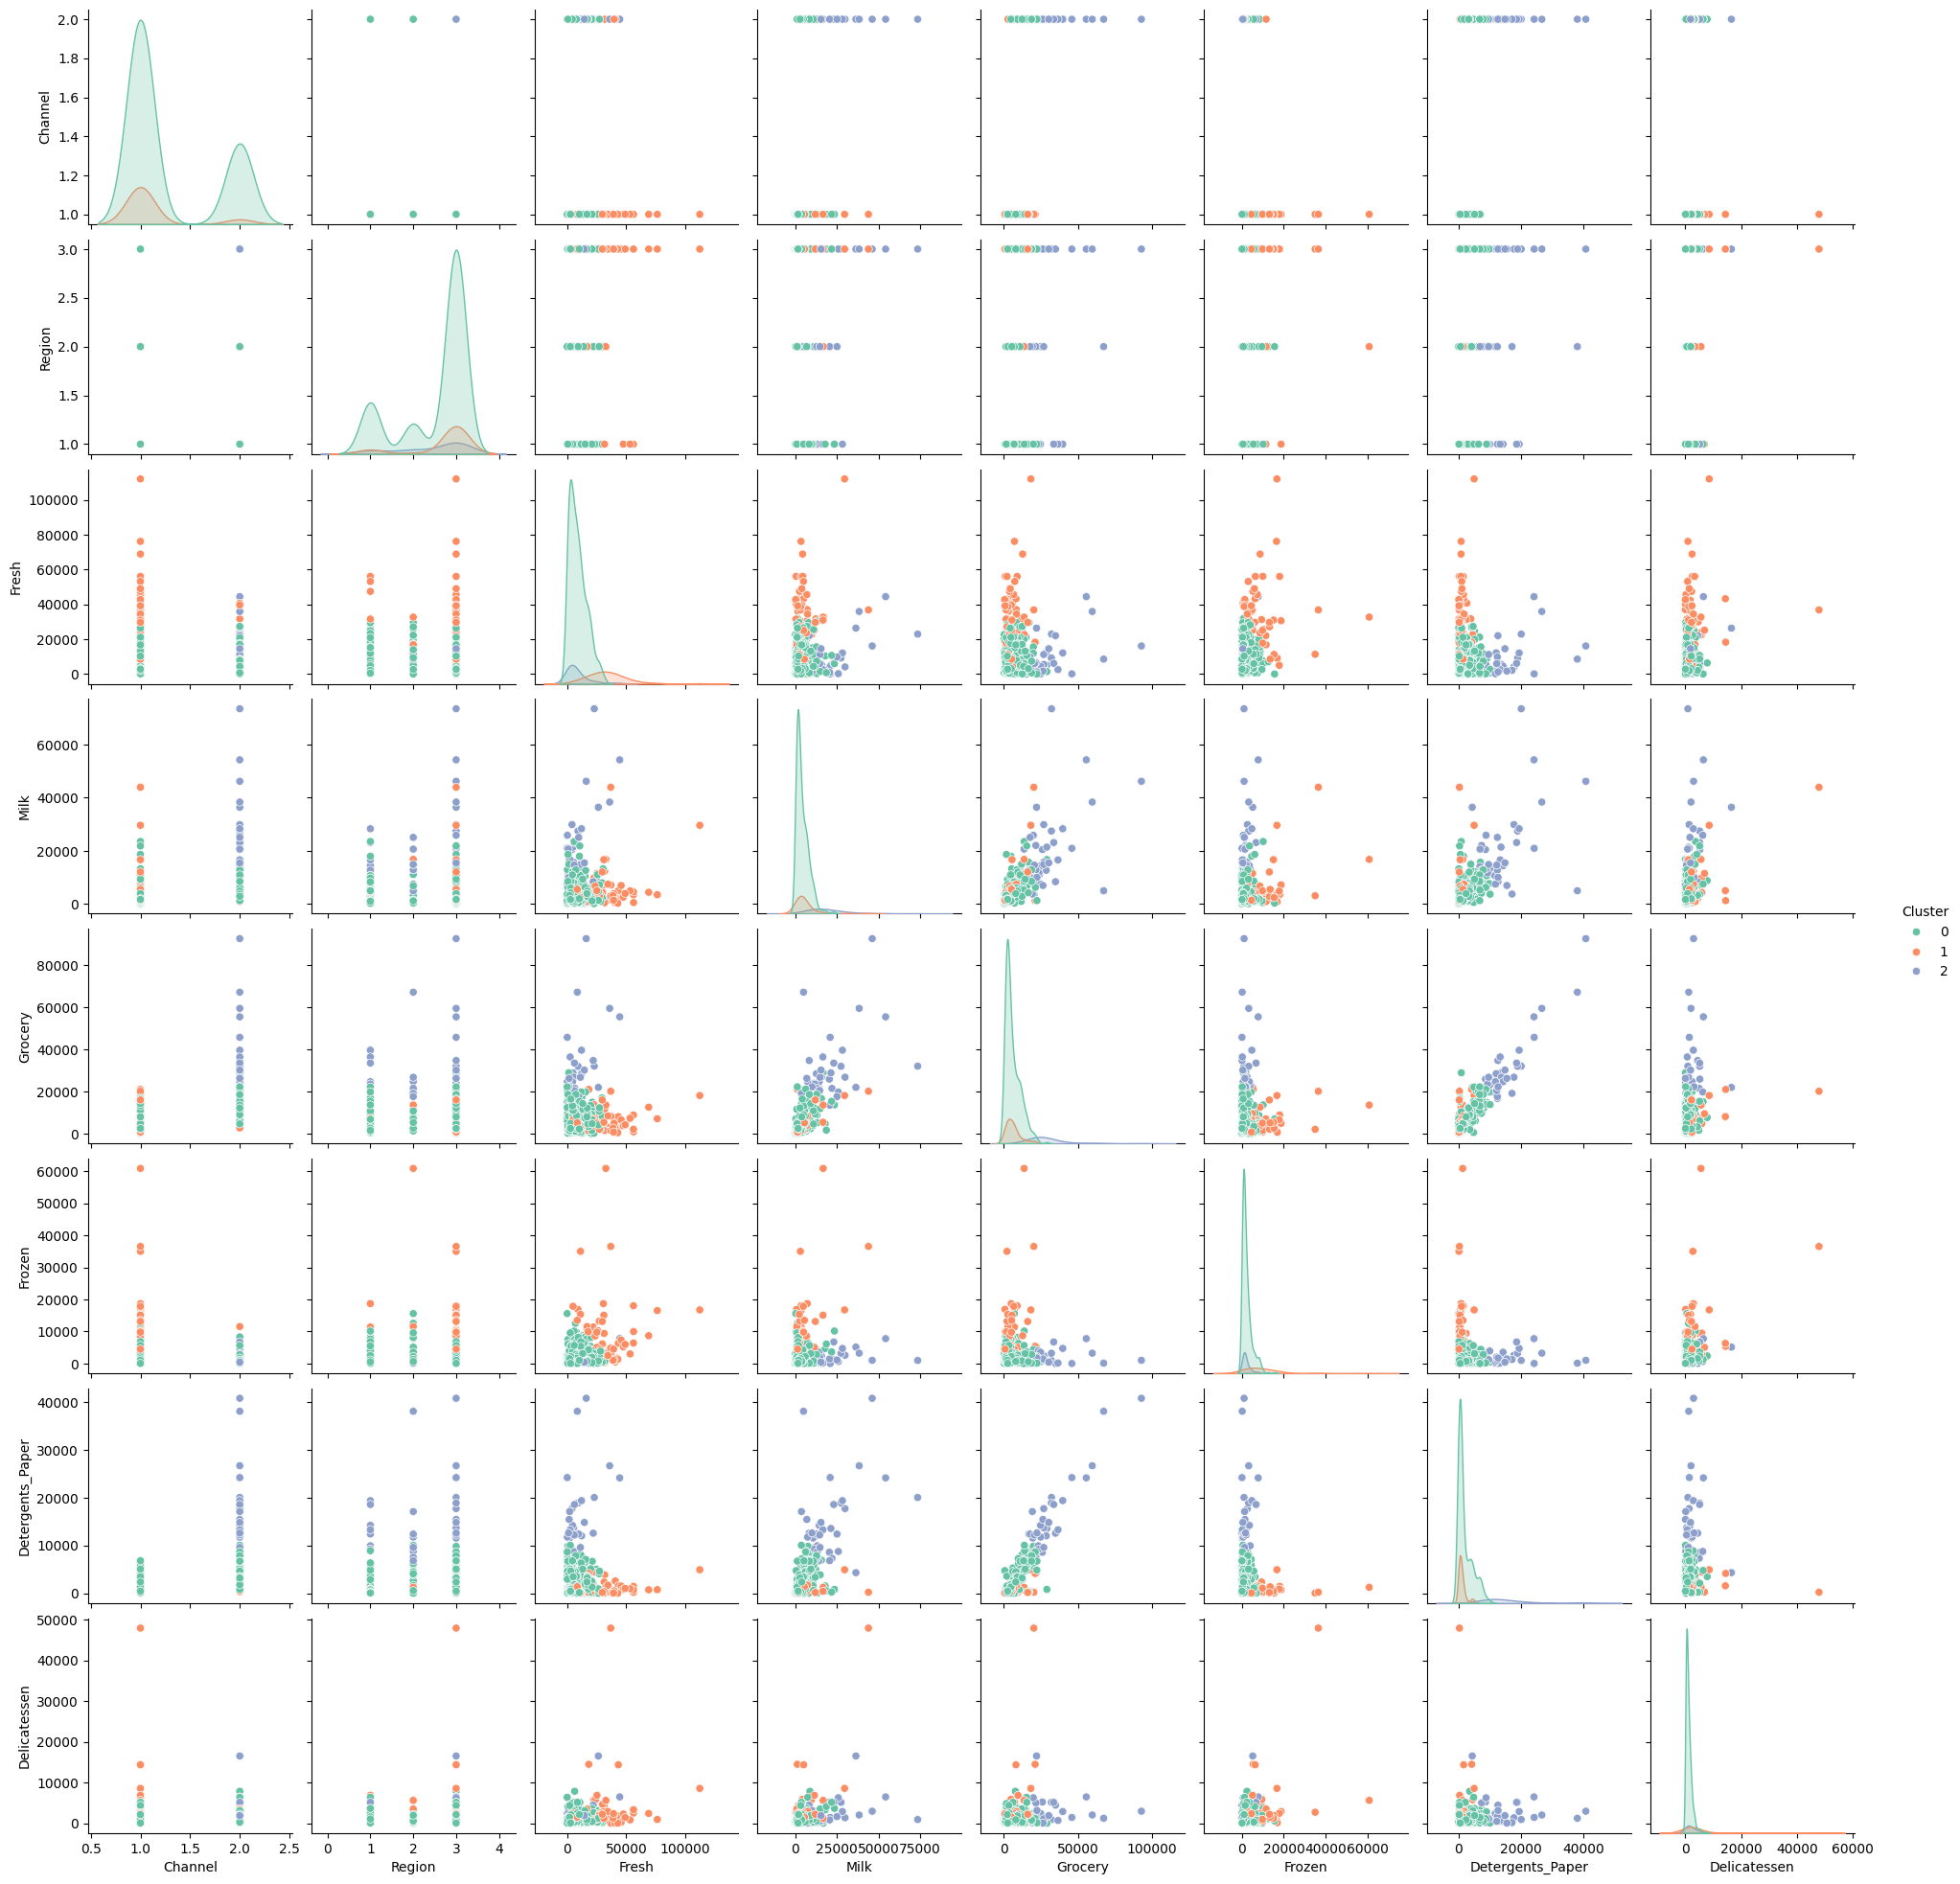

In [13]:
# Visualize Clusters
sns.pairplot(df, hue='Cluster', palette='Set2')
plt.show()

# Analyze Results

In [14]:
# Analyze the mean values of each cluster
print(df.groupby('Cluster').mean())

          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.282857  2.534286   8935.500000   4228.528571   5848.034286   
1        1.113208  2.698113  34540.113208   5860.358491   6122.622642   
2        2.000000  2.405405   8704.864865  20534.405405  30466.243243   

              Frozen  Detergents_Paper  Delicatessen  
Cluster                                               
0        2167.231429       1913.605714   1102.120000  
1        9841.735849        981.471698   3664.245283  
2        1932.621622      14758.837838   2459.351351  


In [15]:
# feature and target selection
X=df.iloc[:,:-1] #feature
y=df.iloc[:,-1]  # target

In [16]:
# train test split
Xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.3, random_state = 1)

# Decision Trees Classifier model
interpretable model that splits the data into decision paths.

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)

In [18]:
dt_model.fit(Xtrain, ytrain)

DecisionTreeClassifier(random_state=42)

In [19]:
dt_predictions = dt_model.predict(xtest)

In [20]:
# Evaluate Performance
print(classification_report(ytest, dt_predictions))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       102
           1       0.78      0.88      0.82        16
           2       0.80      0.57      0.67        14

    accuracy                           0.92       132
   macro avg       0.84      0.81      0.82       132
weighted avg       0.91      0.92      0.91       132



# Random Forest
An ensemble method that combines multiple decision trees for improved accuracy.

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [22]:
rf_model.fit(Xtrain, ytrain)

RandomForestClassifier(random_state=42)

In [23]:
rf_predictions = rf_model.predict(xtest)

In [24]:
# Evaluate Performance
print(classification_report(ytest, rf_predictions))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       102
           1       0.85      0.69      0.76        16
           2       0.85      0.79      0.81        14

    accuracy                           0.92       132
   macro avg       0.88      0.81      0.84       132
weighted avg       0.91      0.92      0.91       132



# K-Nearest Neighbors (KNN)
Predicts outcomes based on proximity to other data points.

In [25]:
knn_model = KNeighborsClassifier(n_neighbors=5)  # Adjust n_neighbors based on data

In [26]:
knn_model.fit(Xtrain, ytrain)

KNeighborsClassifier()

In [27]:
knn_predictions = knn_model.predict(xtest)

In [28]:
# Evaluate Performance
print(classification_report(ytest, knn_predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       102
           1       0.93      0.88      0.90        16
           2       0.92      0.86      0.89        14

    accuracy                           0.95       132
   macro avg       0.94      0.90      0.92       132
weighted avg       0.95      0.95      0.95       132



# Boosting (e.g., Gradient Boosting, XGBoost)
Boosting combines weak learners to create a strong predictive model.

In [29]:
gb_model = GradientBoostingClassifier(random_state=42)

In [30]:
gb_model.fit(Xtrain, ytrain)

GradientBoostingClassifier(random_state=42)

In [31]:
gb_predictions = gb_model.predict(xtest)

In [32]:
# Evaluate Performance
print(classification_report(ytest, gb_predictions))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       102
           1       0.82      0.88      0.85        16
           2       0.83      0.71      0.77        14

    accuracy                           0.92       132
   macro avg       0.87      0.85      0.86       132
weighted avg       0.92      0.92      0.92       132



# Support Vector Machine (SVM)
Separates data using hyperplanes; great for high-dimensional data.

In [33]:
svm_model = SVC(kernel='linear')  # Use 'rbf' or 'poly' for non-linear data

In [34]:
svm_model.fit(Xtrain, ytrain)

SVC(kernel='linear')

In [35]:
svm_predictions = svm_model.predict(xtest)

In [36]:
# Evaluate Performance
print(classification_report(ytest, svm_predictions))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       102
           1       0.94      1.00      0.97        16
           2       0.80      0.86      0.83        14

    accuracy                           0.96       132
   macro avg       0.91      0.94      0.93       132
weighted avg       0.96      0.96      0.96       132



# Analysis:
1. The comparison of six classification models (Decision Tree, Random Forest, K-Neighbors, Gradient Boosting, and SVC with linear kernel) shows varying degrees of performance.
2. K-Neighbors Classifier and SVC (linear kernel) outperform the other models, achieving the highest accuracy (0.95 and 0.96, respectively) and F1-scores (0.92 and 0.93, respectively).
3.  K-Neighbors Classifier and SVC (linear kernel) may be suitable choices for this classification task